In [2]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print(os.getcwd())      # should be D:\project_data
print(os.listdir("src"))

d:\project_data
['counting.py', 'cv_test.py', 'features.py', 'generate_shapes.py', 'hard_scenes.py', 'preprocess.py', 'schema.sql', '__pycache__']


In [3]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import sqlite3
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocess import shape_mask

conn = sqlite3.connect("data/shapes.db")
df = pd.read_sql("SELECT id, path, label, source, split FROM images", conn)


def image_stats(path):
    img = cv2.imread(path)
    h, w = img.shape[:2]
    border = np.concatenate([img[0], img[-1], img[:, 0], img[:, -1]])
    b, g, r = np.median(border, axis=0)
    frac = (shape_mask(img) > 0).mean()          # fraction of the image covered by the shape
    return h, w, r, g, b, frac


stats = [image_stats(p) for p in df["path"]]      # takes about a minute
df[["height", "width", "bg_r", "bg_g", "bg_b", "shape_frac"]] = stats
df["bg_brightness"] = df[["bg_r", "bg_g", "bg_b"]].mean(axis=1)

In [4]:
cur = conn.cursor()
for col in ["height INTEGER", "width INTEGER", "bg_r REAL", "bg_g REAL", "bg_b REAL", "shape_frac REAL"]:
    try:
        cur.execute(f"ALTER TABLE images ADD COLUMN {col}")
    except sqlite3.OperationalError:
        pass                                       # column already exists if you rerun

cur.executemany(
    "UPDATE images SET height=?, width=?, bg_r=?, bg_g=?, bg_b=?, shape_frac=? WHERE id=?",
    [(int(r.height), int(r.width), r.bg_r, r.bg_g, r.bg_b, r.shape_frac, int(r.id))
     for r in df.itertuples()])
conn.commit()

print(pd.read_sql("""SELECT source, COUNT(*) n, AVG(width) w, AVG(shape_frac) frac
                     FROM images GROUP BY source""", conn))

          source     n      w      frac
0      generated  1250  128.0  0.203831
1      kaggle_2d  2000  224.0  0.154514
2  kaggle_simple   900  200.0  0.134082


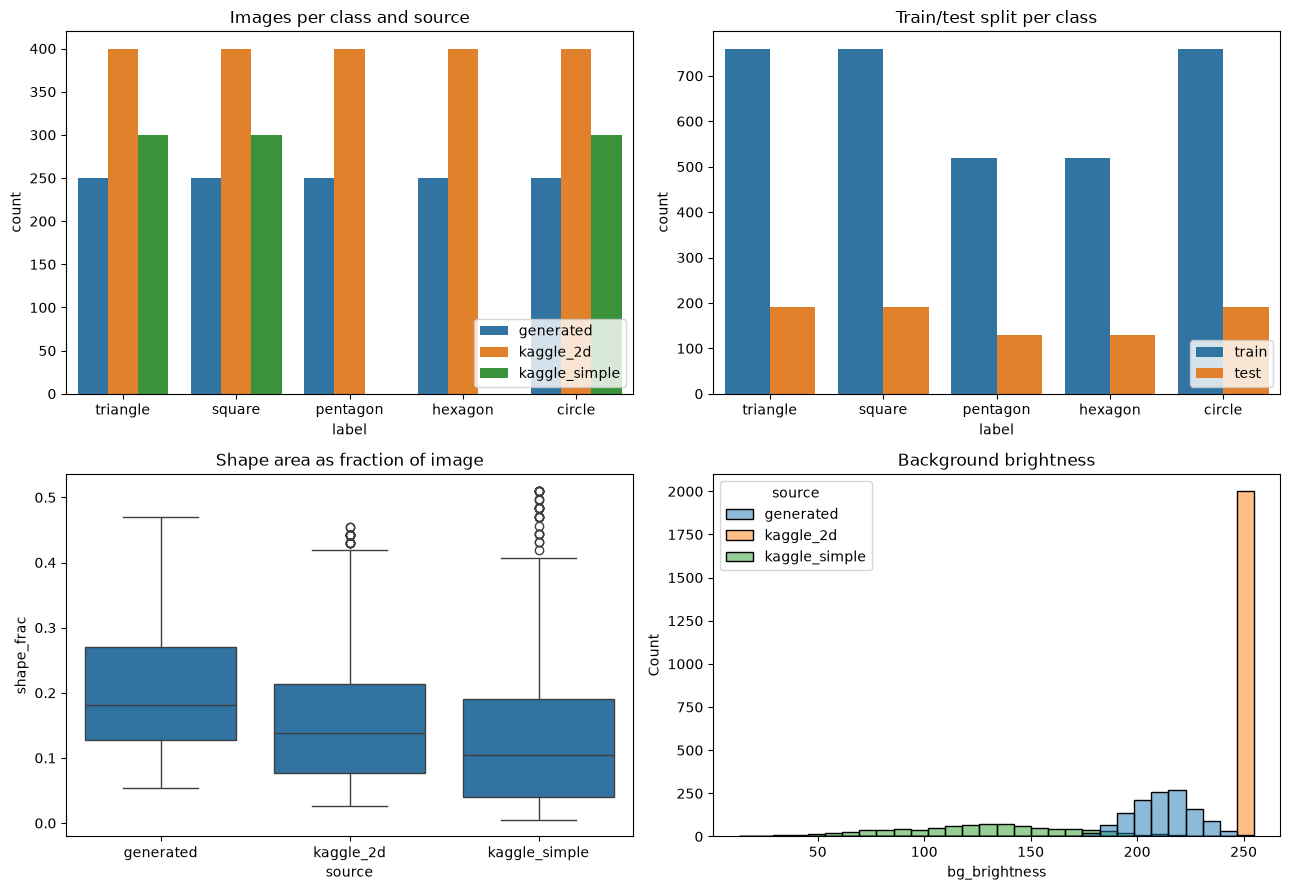

              height         width       
                 min    max    min    max
source                                   
generated      128.0  128.0  128.0  128.0
kaggle_2d      224.0  224.0  224.0  224.0
kaggle_simple  200.0  200.0  200.0  200.0


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# a) class balance per source
sns.countplot(data=df, x="label", hue="source", ax=axes[0, 0])
axes[0, 0].legend(loc="lower right")
axes[0, 0].set_title("Images per class and source")

# b) train/test balance
sns.countplot(data=df, x="label", hue="split", ax=axes[0, 1])
axes[0, 1].legend(loc="lower right")
axes[0, 1].set_title("Train/test split per class")

# c) how much of the image the shape covers
sns.boxplot(data=df, x="source", y="shape_frac", ax=axes[1, 0])
axes[1, 0].set_title("Shape area as fraction of image")

# d) background brightness
sns.histplot(data=df, x="bg_brightness", hue="source", bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Background brightness")

plt.tight_layout()
plt.show()

print(df.groupby("source")[["height", "width"]].agg(["min", "max"]))

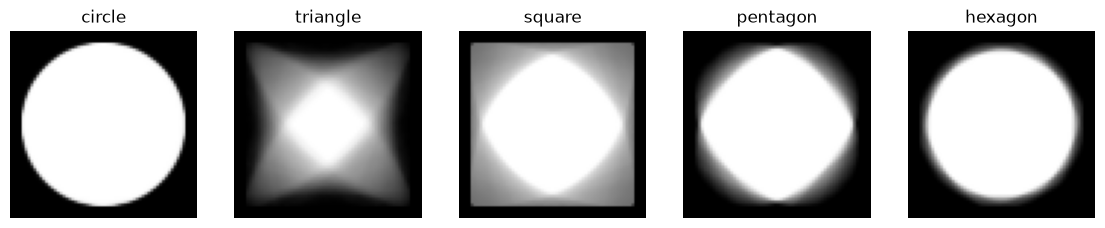

In [6]:
X = np.load("data/processed/silhouettes_64.npz")["X"]
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, c in zip(axes, ["circle", "triangle", "square", "pentagon", "hexagon"]):
    idx = df.index[df.label == c]                  # df order matches X because ids are 1..4150 in order
    ax.imshow(X[idx].mean(axis=0), cmap="gray")
    ax.set_title(c); ax.axis("off")
plt.show()

In [7]:
fig.savefig("outputs/eda_overview.png", dpi=150, bbox_inches="tight")